In [113]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT / "src"))

from compare.plots import (
    plot_lines, plot_eer, plot_f1, plot_pareto, plot_loss_curves, plot_loss_vs_eer,
    plot_gmm_components, plot_gmm_diag_vs_full, _filter,
)

df = pd.read_parquet(ROOT / "results" / "sweep.parquet")

# Slide 1: GMM-only comparison

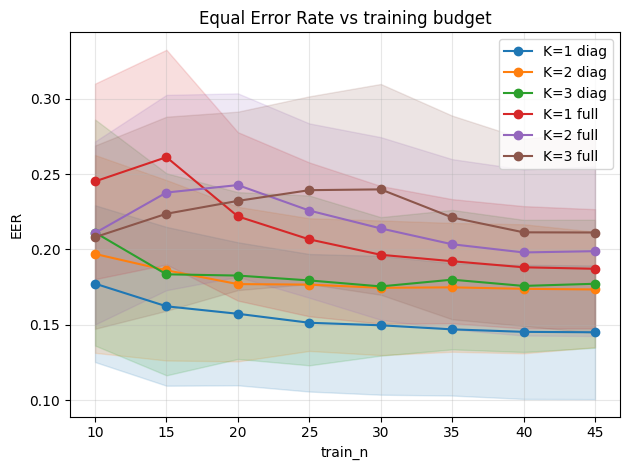

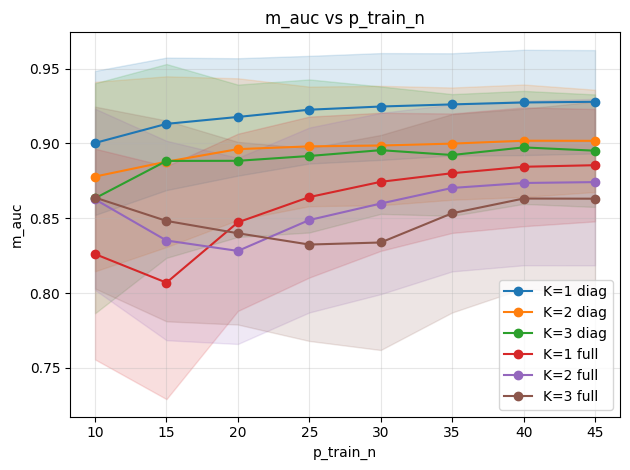

In [114]:
gmm_lines = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
]

plot_eer(df, lines=gmm_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=gmm_lines)

# Slide 1b: GMM diag vs full covariance

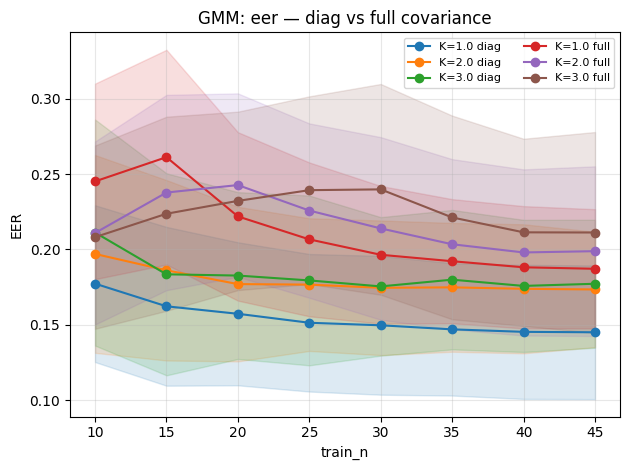

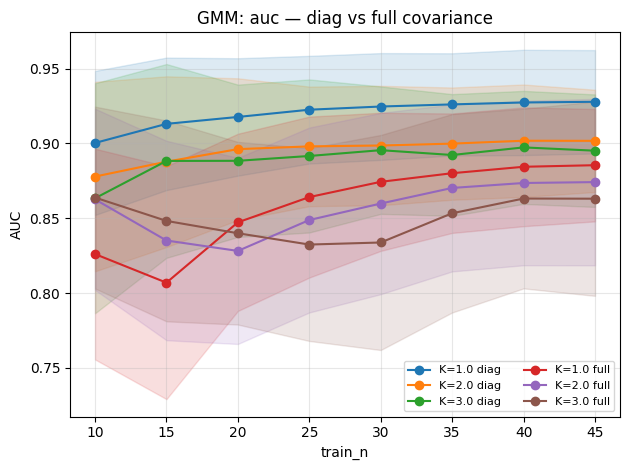

In [115]:
plot_gmm_diag_vs_full(df, y="m_eer")
plot_gmm_diag_vs_full(df, y="m_auc")
plt.show()

# Slide 1c: GMM optimal K

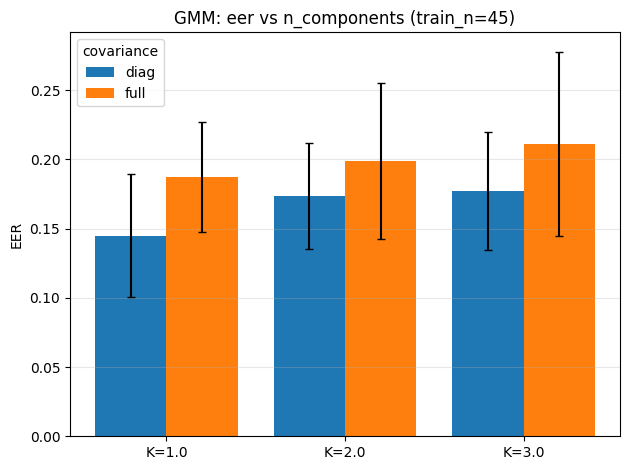

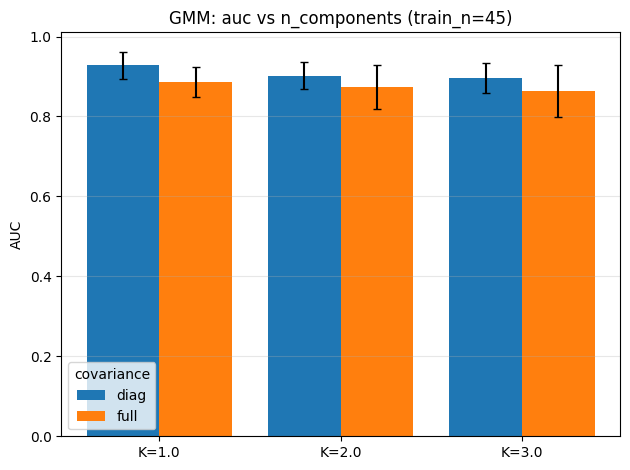

In [116]:
plot_gmm_components(df, y="m_eer", fixed_train_n=45)
plot_gmm_components(df, y="m_auc", fixed_train_n=45)
plt.show()

# Slide 1d: GMM EER per target word (diag vs full)

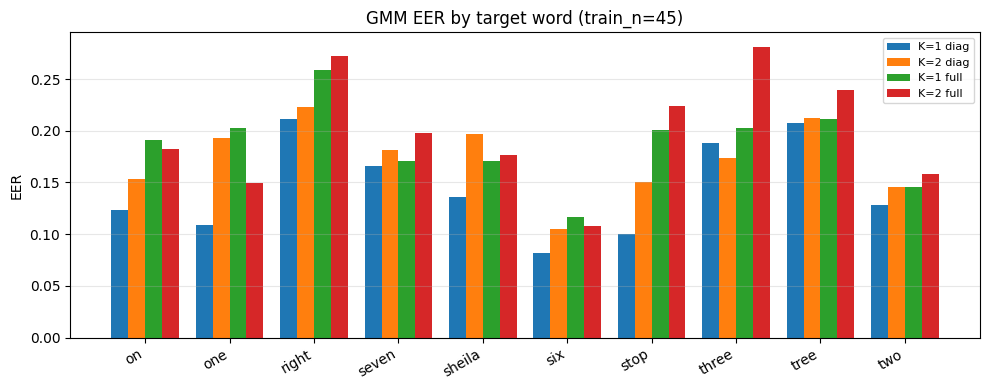

In [117]:
gmm_word_lines = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
]

fixed_train_n = 45
sub = df[df["p_train_n"] == fixed_train_n]
words = sorted(df["p_target_class"].unique())
x = range(len(words))
width = 0.8 / len(gmm_word_lines)

fig, ax = plt.subplots(figsize=(10, 4))
for i, (label, where) in enumerate(gmm_word_lines):
    means = [_filter(sub, where).groupby("p_target_class")["m_eer"].mean().get(w, float("nan")) for w in words]
    offset = (i - len(gmm_word_lines) / 2 + 0.5) * width
    ax.bar([xi + offset for xi in x], means, width=width, label=label)

ax.set_xticks(list(x))
ax.set_xticklabels(words, rotation=30, ha="right")
ax.set_ylabel("EER")
ax.set_title(f"GMM EER by target word (train_n={fixed_train_n})")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 1e: Statistical significance (paired t-tests)

In [118]:
import numpy as np
from scipy import stats

TRAIN_N = 45
sub = df[df["p_train_n"] == TRAIN_N]
idx = ["p_trial", "p_target_class"]

def paired_test(a_eer, b_eer):
    """Return (n, mean_diff, cohen_d, t, p) for b - a."""
    paired = pd.concat([a_eer.rename("a"), b_eer.rename("b")], axis=1).dropna()
    diff = paired["b"] - paired["a"]
    d = diff.mean() / diff.std()
    t, p = stats.ttest_rel(paired["b"], paired["a"])
    return len(paired), diff.mean(), d, t, p

def get_eer(where: dict):
    mask = pd.Series(True, index=sub.index)
    for k, v in where.items():
        mask &= sub[k] == v
    return sub[mask].set_index(idx)["m_eer"]

# Define all configs to compare
configs = {
    "GMM K=1 diag": {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"},
    "GMM K=2 diag": {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"},
    "GMM K=3 diag": {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"},
    "GMM K=1 full": {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"},
    "GMM K=2 full": {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"},
    "GMM K=3 full": {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"},
    "SmallAE ep=100": {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 100},
    "SmallAE ep=50":  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 50},
    "SmallAE ep=10":  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 10},
    "kNN k=1": {"p_adapter": "KNNAdapter", "p_k": 1},
    "kNN k=2": {"p_adapter": "KNNAdapter", "p_k": 2},
}

# All pairwise comparisons
config_names = list(configs.keys())
rows = []
for i in range(len(config_names)):
    for j in range(i + 1, len(config_names)):
        a_name, b_name = config_names[i], config_names[j]
        a_eer = get_eer(configs[a_name])
        b_eer = get_eer(configs[b_name])
        if a_eer.empty or b_eer.empty:
            continue
        n, md, d, t, p = paired_test(a_eer, b_eer)
        rows.append({"A": a_name, "B": b_name, "n_pairs": n,
                      "mean_diff": md, "cohen_d": d, "t_stat": t, "p_value": p})

res = pd.DataFrame(rows)
res["sig"] = res["p_value"].apply(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns")
print(f"Paired t-tests on EER at train_n={TRAIN_N}  (positive diff = B is worse)\n")
print(res.to_string(index=False, float_format="%.4f"))

Paired t-tests on EER at train_n=45  (positive diff = B is worse)

             A              B  n_pairs  mean_diff  cohen_d   t_stat  p_value sig
  GMM K=1 diag   GMM K=2 diag      100     0.0284   0.9005   9.0051   0.0000 ***
  GMM K=1 diag   GMM K=3 diag      100     0.0322   0.8857   8.8573   0.0000 ***
  GMM K=1 diag   GMM K=1 full      100     0.0421   1.1957  11.9573   0.0000 ***
  GMM K=1 diag   GMM K=2 full      100     0.0538   1.4658  14.6576   0.0000 ***
  GMM K=1 diag   GMM K=3 full      100     0.0662   1.4339  14.3393   0.0000 ***
  GMM K=1 diag SmallAE ep=100      100     0.0565   0.6408   6.4083   0.0000 ***
  GMM K=1 diag  SmallAE ep=50      100     0.1275   0.9806   9.8062   0.0000 ***
  GMM K=1 diag  SmallAE ep=10      100     0.3231   2.0750  20.7504   0.0000 ***
  GMM K=1 diag        kNN k=1      100     0.0461   1.2770  12.7696   0.0000 ***
  GMM K=1 diag        kNN k=2      100     0.0255   1.1413  11.4135   0.0000 ***
  GMM K=2 diag   GMM K=3 diag      100    

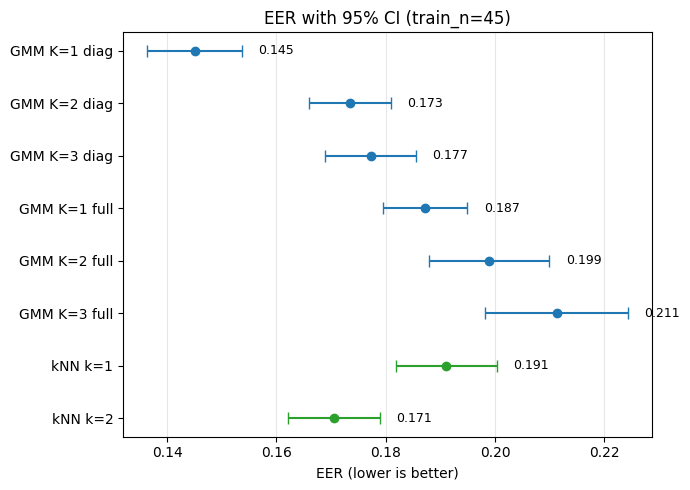

In [119]:
# 95% CI plot for EER at train_n=45
ci_configs = [
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
    # ("SmallAE ep=10",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 10}),
    # ("SmallAE ep=50",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 50}),
    # ("SmallAE ep=100", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 100}),
    ("kNN k=1", {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2", {"p_adapter": "KNNAdapter", "p_k": 2}),
]

colors = {
    "GMMAdapter": "tab:blue",
    "SmallAEAdapter": "tab:orange",
    "KNNAdapter": "tab:green",
}

fig, ax = plt.subplots(figsize=(7, 5))
for i, (label, where) in enumerate(ci_configs):
    mask = pd.Series(True, index=sub.index)
    for k, v in where.items():
        mask &= sub[k] == v
    vals = sub[mask]["m_eer"]
    mean = vals.mean()
    ci = 1.96 * vals.std() / np.sqrt(len(vals))
    color = colors[where["p_adapter"]]
    ax.errorbar(mean, i, xerr=ci, fmt="o", color=color, capsize=4)
    ax.text(mean + ci + 0.003, i, f"{mean:.3f}", va="center", fontsize=9)

ax.set_yticks(range(len(ci_configs)))
ax.set_yticklabels([c[0] for c in ci_configs])
ax.set_xlabel("EER (lower is better)")
ax.set_title(f"EER with 95% CI (train_n={TRAIN_N})")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 2: Best GMMs vs SmallAE vs kNN

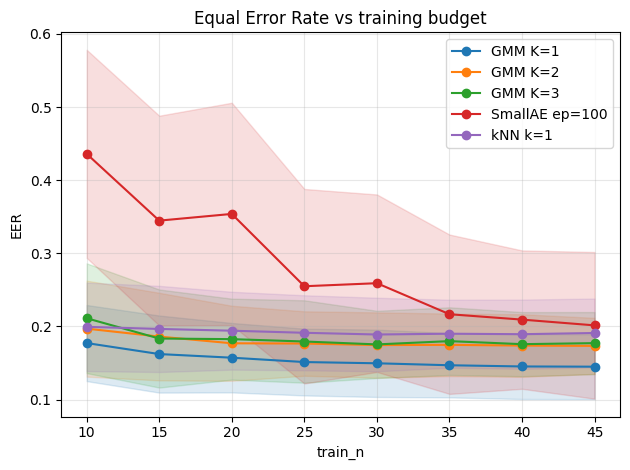

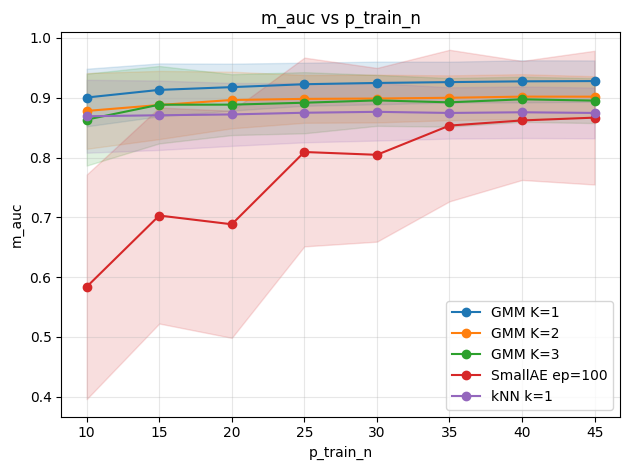

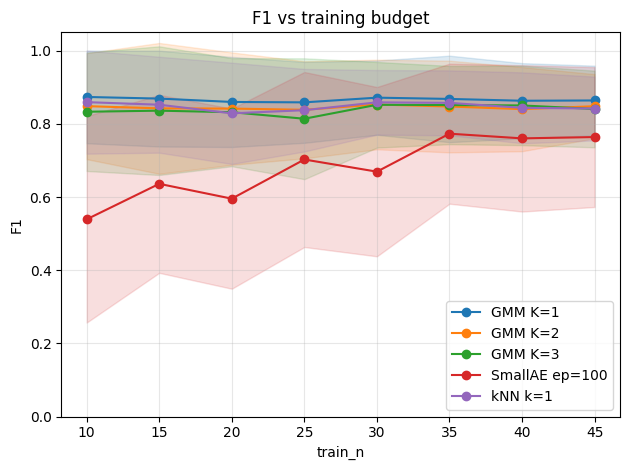

In [120]:
compare_lines = [
    ("GMM K=1",      {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2",      {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3",      {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("SmallAE ep=100", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 100}),
    ("kNN k=1",      {"p_adapter": "KNNAdapter", "p_k": 1}),
]

plot_eer(df, lines=compare_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=compare_lines)
plot_f1(df, lines=compare_lines)

# Slide 3: Training MACs comparison

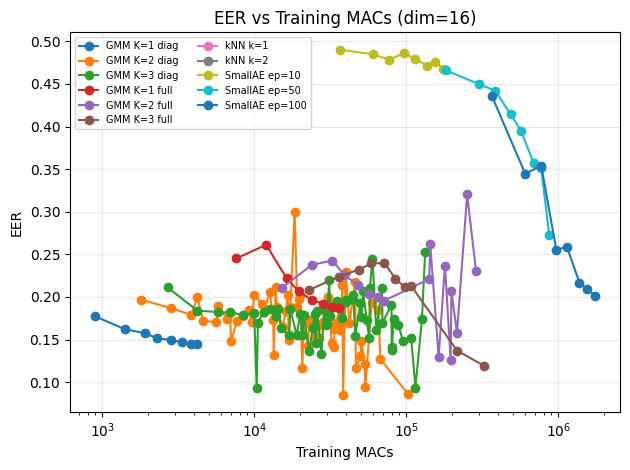

In [121]:
mac_lines = [
    # GMMs — diag
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),

    # GMMs — full
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),

    # kNNs
    ("kNN k=1",      {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2",      {"p_adapter": "KNNAdapter", "p_k": 2}),

    # AEs
    ("SmallAE ep=10",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 10}),
    ("SmallAE ep=50",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 50}),
    ("SmallAE ep=100", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 100}),
]

from compare.plots import _filter, _agg
for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    for label, where in mac_lines:
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_training_macs", "m_eer")
        ax.plot(agg["m_training_macs"], agg["mean"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Training MACs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Training MACs (dim={dim})")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 4: MAC-fair comparison (low-epoch SmallAE vs GMM)

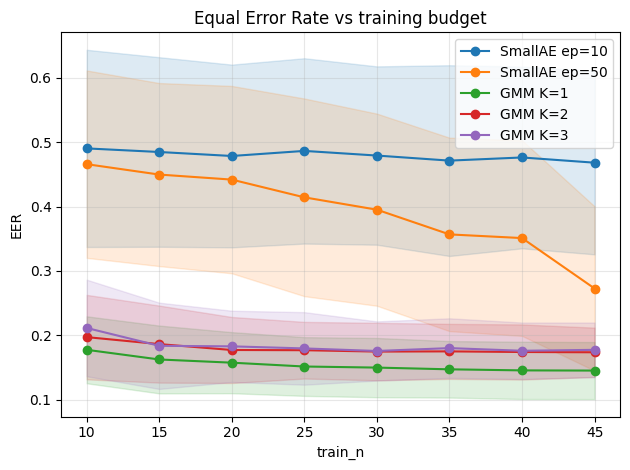

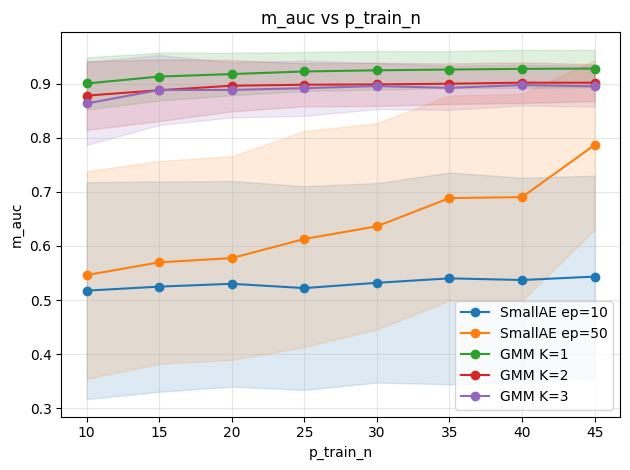

In [122]:
fair_lines = [
    ("SmallAE ep=10",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 10}),
    ("SmallAE ep=50",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 50}),
    ("GMM K=1",      {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2",      {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3",      {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
]

plot_eer(df, lines=fair_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=fair_lines)

# Slide 5: Training MACs (low-epoch SmallAE vs GMM)

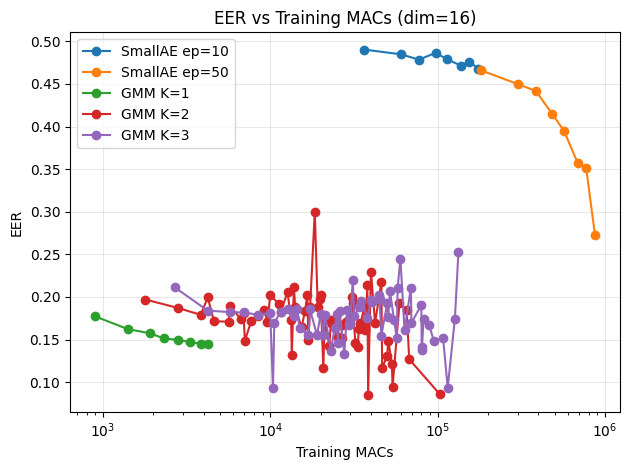

In [123]:
for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    for label, where in fair_lines:
        from compare.plots import _filter, _agg
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_training_macs", "m_eer")
        ax.plot(agg["m_training_macs"], agg["mean"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Training MACs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Training MACs (dim={dim})")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 6: EER variance across target words

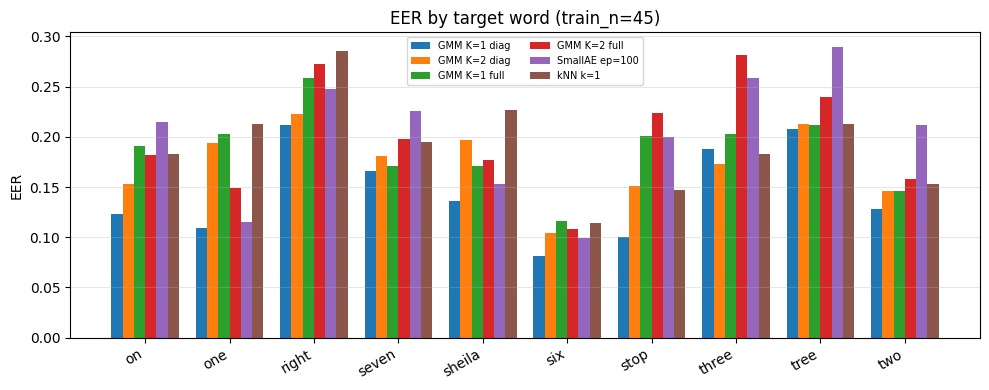

In [124]:
target_lines = [
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("SmallAE ep=100", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 100}),
    ("kNN k=1",   {"p_adapter": "KNNAdapter", "p_k": 1}),
]

# EER per target word at fixed train_n — shows which words are harder to enroll
fixed_train_n = 45
sub = df[df["p_train_n"] == fixed_train_n]

fig, ax = plt.subplots(figsize=(10, 4))
words = sorted(df["p_target_class"].unique())
x = range(len(words))
width = 0.8 / len(target_lines)
for i, (label, where) in enumerate(target_lines):
    means = [_filter(sub, where).groupby("p_target_class")["m_eer"].mean().get(w, float("nan")) for w in words]
    offset = (i - len(target_lines) / 2 + 0.5) * width
    ax.bar([xi + offset for xi in x], means, width=width, label=label)

ax.set_xticks(list(x))
ax.set_xticklabels(words, rotation=30, ha="right")
ax.set_ylabel("EER")
ax.set_title(f"EER by target word (train_n={fixed_train_n})")
ax.legend(fontsize=7, ncol=2)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 7: Pareto frontier — iso-MAC comparison

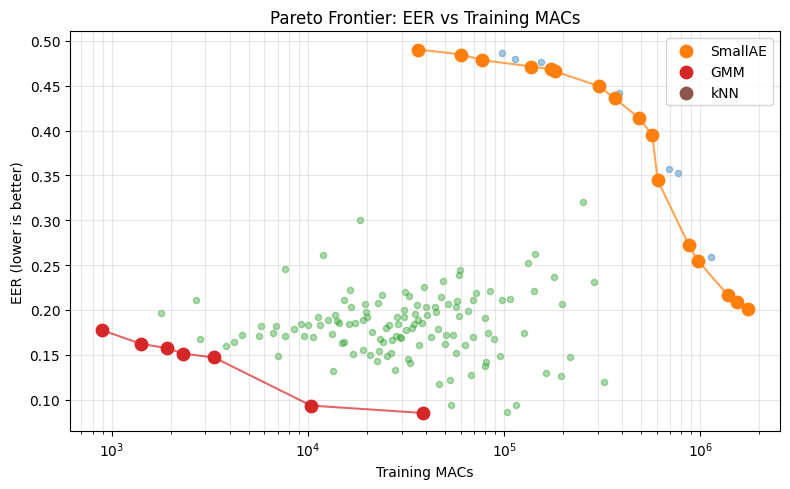

In [125]:
from compare.plots import plot_pareto

pareto_lines = [
    ("SmallAE", {"p_adapter": "SmallAEAdapter"}),
    ("GMM",     {"p_adapter": "GMMAdapter"}),
    ("kNN",     {"p_adapter": "KNNAdapter"}),
]

plot_pareto(df, lines=pareto_lines)
plt.show()

# Slide 8: AE training convergence

TODO: FIXME: the x axis is the percentage of the training wrt the number of iterations.
Make sure to consider this. This should be fixed.

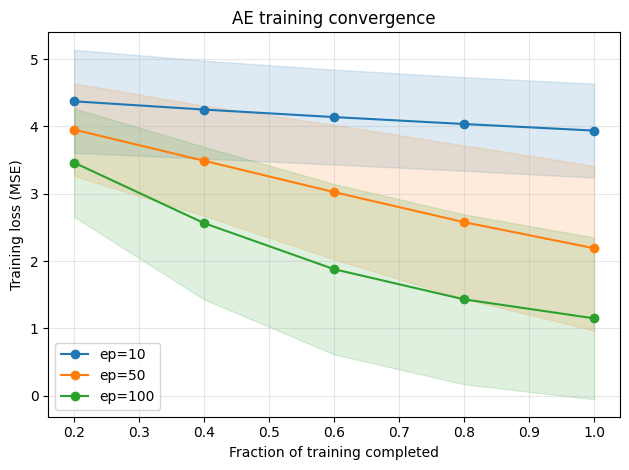

In [126]:
from compare.plots import plot_loss_curves, plot_loss_vs_eer

# Loss curves: is training still improving at the last epoch?
# Each checkpoint is at 20%, 40%, 60%, 80%, 100% of training.
# A line still dropping at x=1.0 means the adapter needs more epochs.
loss_lines = [
    ("ep=10",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 10}),
    ("ep=50",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 50}),
    ("ep=100", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 100}),
]

plot_loss_curves(df, lines=loss_lines)
plt.show()